# PROBLEM STATEMENT

You own an ice cream business and you would like to create a model that could predict the daily revenue in dollars based on the outside air temperature (degC). You decide that a Linear Regression model might be a good candidate to solve this problem.  
Data set:
- Independant variable X: Outside Air Temperature
- Dependant variable Y: Overall daily revenue generated in dollars

# STEP #1: LIBRARIES IMPORT


In [196]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# STEP #2: IMPORT DATASET

In [197]:
IceCream = pd.read_csv("https://raw.githubusercontent.com/renatomaaliw3/public_files/refs/heads/master/Data%20Sets/IceCreamData.csv")

In [198]:
IceCream.head(100)

,Temperature,Revenue
0,24.566884,534.799028
1,26.005191,625.190122
2,27.790554,660.632289
3,20.595335,487.706960
4,11.503498,316.240194
...,...,...
95,9.018860,212.591740
96,20.265012,474.749392
97,19.363153,460.402500
98,14.685944,343.362905


In [199]:
IceCream.tail()

,Temperature,Revenue
495,22.274899,524.746364
496,32.893092,755.818399
497,12.588157,306.090719
498,22.362402,566.217304
499,28.957736,655.660388


In [200]:
IceCream.describe()

,Temperature,Revenue
count,500.000000,500.000000
mean,22.232225,521.570777
std,8.096388,175.404751
min,0.000000,10.000000
25%,17.122258,405.558681
50%,22.392791,529.368565
75%,27.740674,642.257922
max,45.000000,1000.000000


In [201]:
IceCream.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  500 non-null    float64
 1   Revenue      500 non-null    float64
dtypes: float64(2)
memory usage: 7.9 KB


# STEP#3: VISUALIZE DATASET

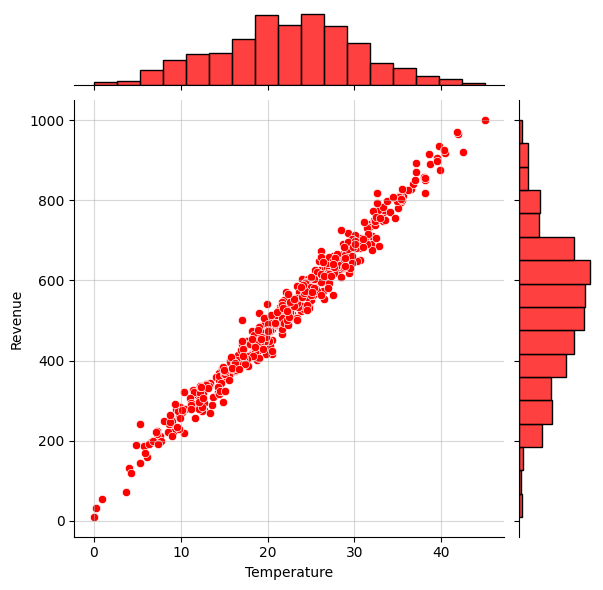

In [202]:
# Joint Plot (Scatter Plot and Distribution)

sns.jointplot(x='Temperature', y='Revenue', data = IceCream, color = 'red')
plt.grid(True, alpha = 0.5)

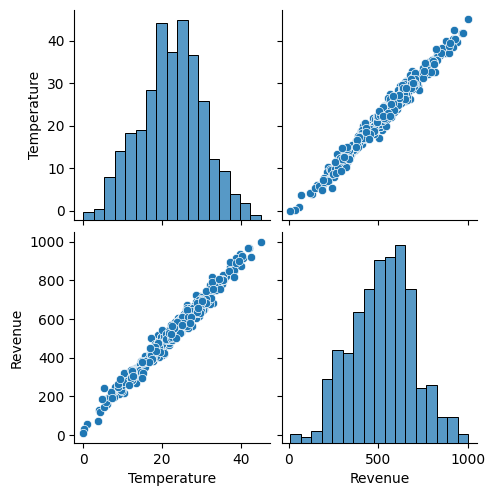

In [203]:
# Pair Plot (Multiple Scatter Plots)

sns.pairplot(IceCream)

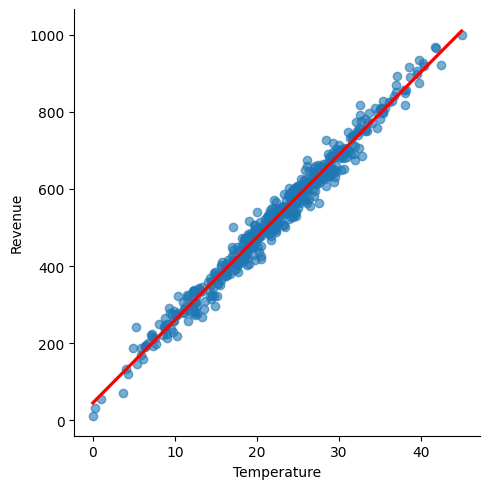

In [204]:
# Linear Model Plot

sns.lmplot(x ='Temperature', y ='Revenue', data = IceCream,
           line_kws = {'color': 'red'},
           scatter_kws = {'alpha': 0.6})

<Axes: xlabel='Temperature', ylabel='Revenue'>

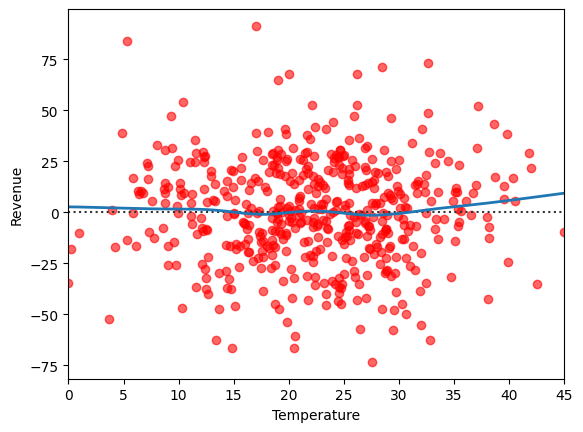

In [205]:
# Identifying Linear Relationships through Residuals

sns.residplot(x = 'Temperature', y = 'Revenue', data = IceCream,
              lowess = True, scatter_kws = {'alpha': 0.6, 'color': 'red'}, line_kws = {'lw': 2})

# Linear-ish: points look randomly scattered around 0, and the LOWESS line stays near 0 and fairly flat

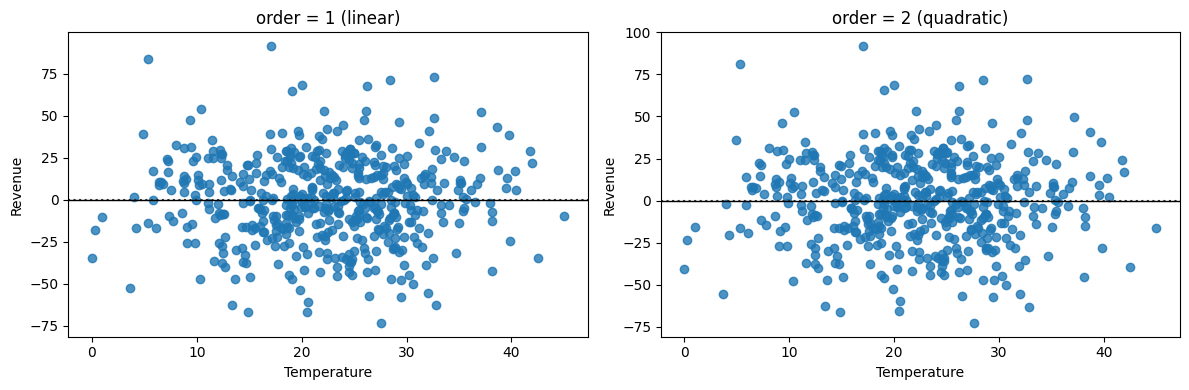

In [206]:
# Identifying Linear Relationships through Residuals

fig, axes = plt.subplots(1, 2, figsize = (12, 4))

sns.residplot(data = IceCream, x="Temperature", y="Revenue", order=1, ax=axes[0])
axes[0].axhline(0, color="k", lw=1)
axes[0].set_title("order = 1 (linear)")

sns.residplot(data = IceCream, x="Temperature", y="Revenue", order=2, ax=axes[1])
axes[1].axhline(0, color="k", lw=1)
axes[1].set_title("order = 2 (quadratic)")

plt.tight_layout()

# If order = 2 removes the pattern that order=1 shows, that’s evidence the relationship isn’t purely linear.

# STEP#4: CREATE TESTING AND TRAINING DATASET

In [207]:
y = IceCream['Revenue'] # Target

In [208]:
X = IceCream[['Temperature']] # Variable

In [209]:
y

,Revenue
0,534.799028
1,625.190122
2,660.632289
3,487.706960
4,316.240194
...,...
495,524.746364
496,755.818399
497,306.090719
498,566.217304


In [210]:
X

,Temperature
0,24.566884
1,26.005191
2,27.790554
3,20.595335
4,11.503498
...,...
495,22.274899
496,32.893092
497,12.588157
498,22.362402


In [211]:
from sklearn.model_selection import train_test_split

In [212]:
# This is a 75/25 split, where test size is 25% of the data and training size is 75% of the data

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 101)

In [213]:
X_train

,Temperature
433,8.756004
154,23.349034
200,26.873586
53,27.999222
385,12.084601
...,...
63,3.986523
326,25.227774
337,22.118706
11,3.664670


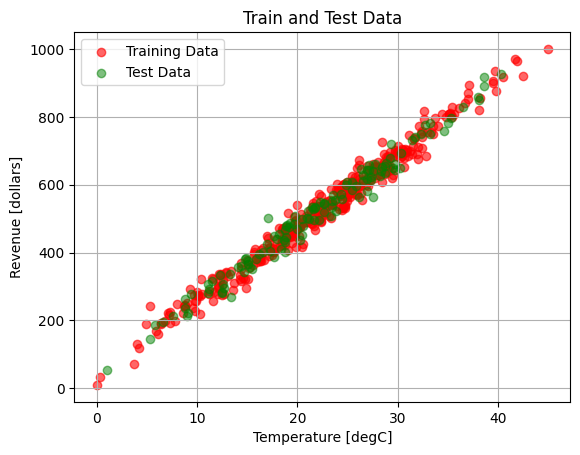

In [214]:
# Visualizae Training and Test Data

plt.scatter(X_train, y_train, color = 'red', alpha = 0.6, label = 'Training Data')
plt.scatter(X_test, y_test, color = 'green', alpha = 0.5, label = 'Test Data')
plt.ylabel('Revenue [dollars]')
plt.xlabel('Temperature [degC]')
plt.title('Train and Test Data')
plt.legend()
plt.grid(True)

# STEP#5: TRAIN THE MODEL

In [215]:
from sklearn.linear_model import LinearRegression

In [216]:
model = LinearRegression(fit_intercept = True)

In [217]:
model.fit(X_train, y_train)

LinearRegression()

In [218]:
print('Linear Model Coefficient (m): ', model.coef_)
print('Linear Model Coefficient (b): ', model.intercept_)

Linear Model Coefficient (m):  [21.47706919]
Linear Model Coefficient (b):  43.81194267632236


# STEP#6: TEST THE MODEL

In [219]:
# Optional as we test the prediction on the test data

train_predict = model.predict(X_train)
train_predict

array([ 231.86524707,  545.28076547,  620.97781371,  645.15318111,
        303.35376156,  584.84991006,  627.68347166,  892.43870219,
        305.60491493,  456.06323896,  686.39100915,  519.58462268,
        685.54618758,  352.2532428 ,  575.98525899,  441.27154973,
        476.13569129,  588.90935061,  440.77564055,  336.42646342,
        457.28104141,  797.54529487,  805.05691421,  956.91556163,
        416.66958458,  558.48584073,  639.18722736,  261.15423161,
        640.45565318,  689.86557971,  646.16651155,  457.86130865,
        588.77343856,  639.31521415,  228.23442202,  421.5586244 ,
        456.23545864,  580.78978095,  320.90422071,  723.97922464,
        501.75443888,  702.44053731,  636.5590013 ,  802.62274529,
        768.53864765,  863.91811111,  600.827789  ,  516.51953607,
        604.83890035,  231.85558039,  472.98537679,  283.86440586,
        439.84870399,  541.07056534,  570.46934154,  535.00458535,
        485.44523491,  733.37791893,  251.09777392,  596.31964

In [220]:
# You predict on test data in practice

test_predict = model.predict(X_test)
test_predict

array([679.30726393, 681.77073681, 614.99575859, 290.8733574 ,
       449.30665458, 445.61517744, 232.61584437, 390.57692463,
       360.37429201, 626.22150995, 622.92430733, 510.98313143,
       237.51062797, 693.43418612, 184.32597705, 409.99033698,
       606.33221214, 546.60863123, 651.58486082, 385.65553347,
       447.83478894, 630.61535921, 377.16101005, 366.99723297,
       546.05630931, 437.84785147, 609.95866853, 368.50649728,
       484.34179851, 576.84603028, 511.49548431, 494.98170417,
       455.5712792 , 168.85857729, 757.94379937, 548.47006514,
       370.93326671, 788.59474626, 613.6032868 , 622.49273443,
       407.95087921, 662.20460188, 566.7593329 , 352.73989922,
       307.35634458, 472.86939031, 909.41875251, 569.86004374,
       520.37771071, 465.24914533, 682.0785713 , 509.7952459 ,
       506.43787205, 640.67159115, 449.37888046, 635.3325436 ,
       359.22298881, 447.08321286, 695.21857448, 206.20274618,
       284.09216997, 503.94865246, 651.00658923, 415.34

In [221]:
# MAPE of Train and Test Data
# actual vs. prediction

from sklearn.metrics import mean_absolute_percentage_error

print(mean_absolute_percentage_error(y_train, train_predict))
print(mean_absolute_percentage_error(y_test, test_predict))

0.05411571383856601
0.04400402172648792


Text(0.5, 1.0, 'Revenue Generated vs. Temperature @Ice Cream Stand (Training dataset)')

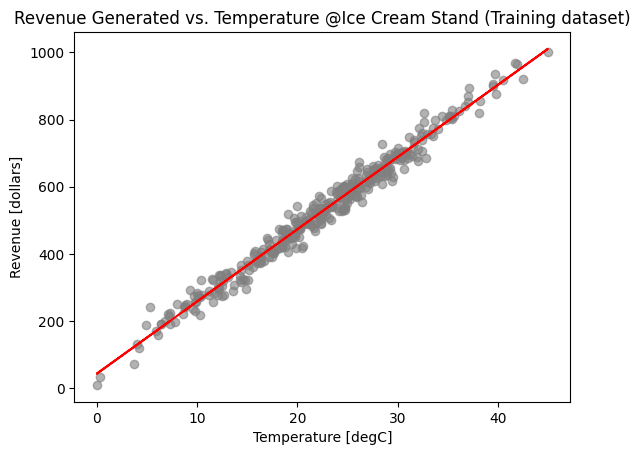

In [222]:
# Training Data Plot

plt.scatter(X_train, y_train, color = 'gray', alpha = 0.6)
plt.plot(X_train, model.predict(X_train), color = 'red')
plt.ylabel('Revenue [dollars]')
plt.xlabel('Temperature [degC]')
plt.title('Revenue Generated vs. Temperature @Ice Cream Stand (Training dataset)')

Text(0.5, 1.0, 'Revenue Generated vs. Hours @Ice Cream Stand (Test dataset)')

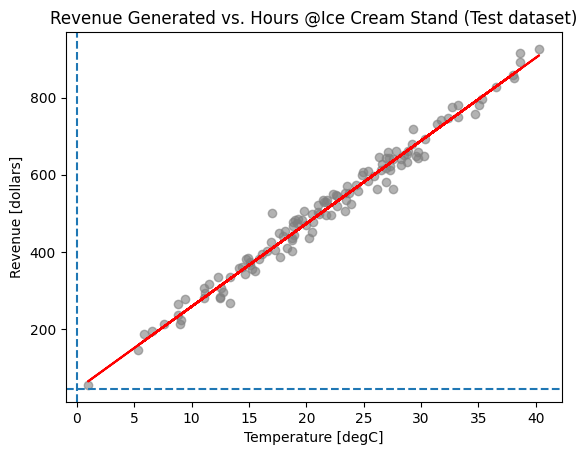

In [223]:
# Test Data Plot

plt.scatter(X_test, y_test, color = 'gray', alpha = 0.6)
plt.plot(X_test, model.predict(X_test), color = 'red')
plt.ylabel('Revenue [dollars]')
plt.xlabel('Temperature [degC]')
plt.axvline(0, ls = '--')
plt.axhline(43.81194267632236, ls = '--')
plt.title('Revenue Generated vs. Hours @Ice Cream Stand (Test dataset)')

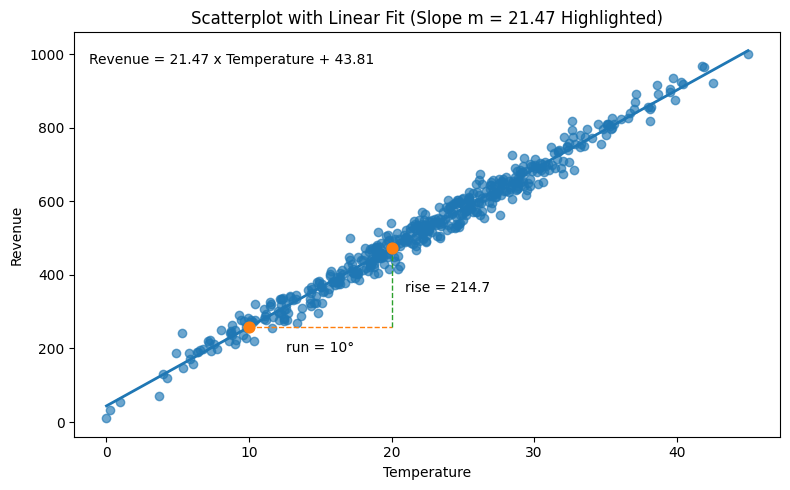

In [224]:
# Visual Explanation

m = 21.47
b = 43.81  # from earlier fitted line equation shown on plot

# Build plot
plt.figure(figsize=(8,5))
plt.scatter(X, y, alpha=0.65)

x_line = np.linspace(X.min(), X.max(), 200)
y_line = m * x_line + b
plt.plot(x_line, y_line, linewidth=2)

# Show slope visually using a "rise over run" from x1 to x2
x1, x2 = 10, 20
y1, y2 = m*x1 + b, m*x2 + b
plt.plot([x1, x2], [y1, y1], linestyle="--", linewidth=1)  # run
plt.plot([x2, x2], [y1, y2], linestyle="--", linewidth=1)  # rise
plt.scatter([x1, x2], [y1, y2], s=60, zorder=5)

plt.annotate(f"run = {x2-x1}°", xy=((x1+x2)/2, y1),
             xytext=(0, -18), textcoords="offset points", ha="center")
plt.annotate(f"rise = {y2-y1:.1f}", xy=(x2, (y1+y2)/2),
             xytext=(10, 0), textcoords="offset points", va="center")

plt.text(0.02, 0.95, f"Revenue = {m:.2f} x Temperature + {b:.2f}",
         transform=plt.gca().transAxes, va="top")

plt.title("Scatterplot with Linear Fit (Slope m = 21.47 Highlighted)")
plt.xlabel("Temperature")
plt.ylabel("Revenue")
plt.tight_layout()


# At 20 deg: 21.47 * 20 + 43.81 = 473.21
# At 21 deg: 21.47 * 21 + 43.81 = 494.68

# 494.68 - 473.21 = 21.47

# For every 1° increase in Temperature,
# the model predicts Revenue increases by about 21.444 units on average

In [225]:
# These will produce warnings but predictions are correct

y_predict = model.predict([[5], [16], [40]])
y_predict

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([151.19728862, 387.4450497 , 902.89471023])

In [226]:
# This is a fix to remove warnings

y_predict = model.predict(pd.DataFrame({'Temperature': [5, 16, 40]}))
y_predict

array([151.19728862, 387.4450497 , 902.89471023])

# EXCELLENT JOB! NOW YOU BECAME EXPERT IN SIMPLE LINEAR REGRESSION